# ResNet-18

Here we are training the ResNet-18, trying out how using a pretrained model, data augmentation, regularization and LR scheduler affect the performance.<br>
We picked ResNet-18 for it's smaller size as the dataset is not big enough and we have problem with overfitting.

In [1]:
from helper_functions import build_dataloaders, build_model, train_model, plot_history, evaluate_model

### ResNet-18 basic
- No pretraining
- No augmentation, regularization
- No LR scheduler

Epoch 1/10 | Train: 45.30% | Val: 33.88% | LR: 0.000100
Epoch 2/10 | Train: 58.47% | Val: 34.28% | LR: 0.000100
Epoch 3/10 | Train: 68.25% | Val: 45.53% | LR: 0.000100
Epoch 4/10 | Train: 82.63% | Val: 47.97% | LR: 0.000100
Epoch 5/10 | Train: 93.07% | Val: 46.34% | LR: 0.000100
Epoch 6/10 | Train: 95.37% | Val: 50.41% | LR: 0.000100
Epoch 7/10 | Train: 97.49% | Val: 49.32% | LR: 0.000100
Epoch 8/10 | Train: 99.27% | Val: 48.51% | LR: 0.000100
Epoch 9/10 | Train: 97.33% | Val: 41.87% | LR: 0.000100
Epoch 10/10 | Train: 96.72% | Val: 49.05% | LR: 0.000100


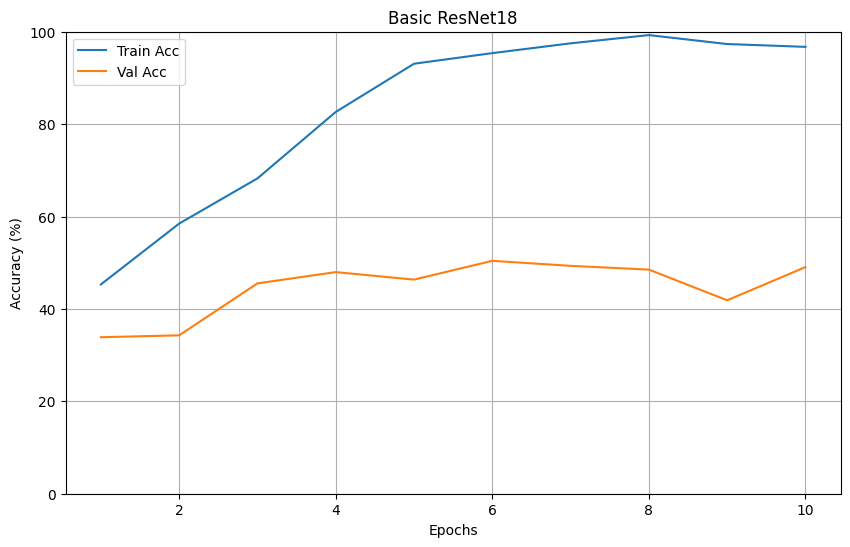


Final Test Accuracy: 52.33%


In [2]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=False
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "Basic ResNet18")

test_accuracy = evaluate_model(model, test_loader)

### Pretrained ResNet-18

- Using a pretrained model
- No augmentation, regularization
- No LR scheduler

Epoch 1/10 | Train: 50.68% | Val: 50.14% | LR: 0.000100
Epoch 2/10 | Train: 69.35% | Val: 53.39% | LR: 0.000100
Epoch 3/10 | Train: 82.73% | Val: 53.25% | LR: 0.000100
Epoch 4/10 | Train: 91.43% | Val: 50.41% | LR: 0.000100
Epoch 5/10 | Train: 96.86% | Val: 54.88% | LR: 0.000100
Epoch 6/10 | Train: 98.69% | Val: 54.20% | LR: 0.000100
Epoch 7/10 | Train: 98.98% | Val: 54.20% | LR: 0.000100
Epoch 8/10 | Train: 98.86% | Val: 51.76% | LR: 0.000100
Epoch 9/10 | Train: 95.03% | Val: 51.22% | LR: 0.000100
Epoch 10/10 | Train: 97.37% | Val: 56.23% | LR: 0.000100


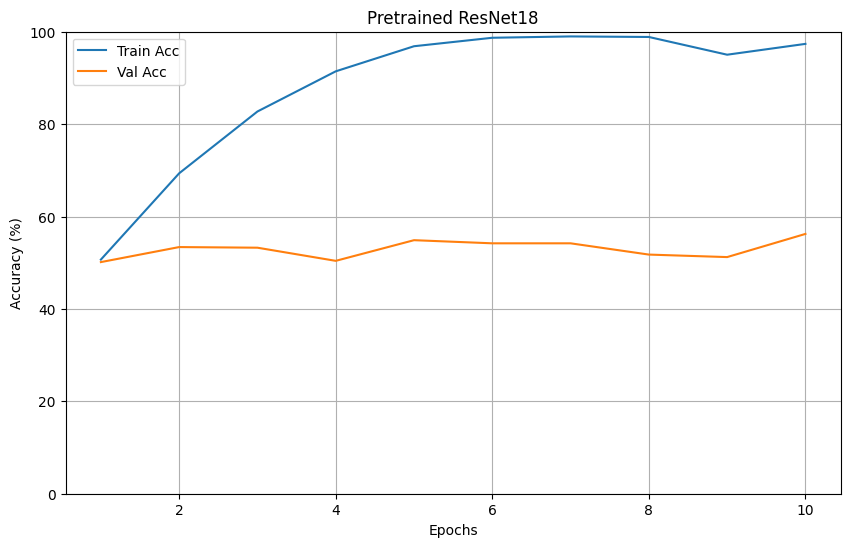


Final Test Accuracy: 60.93%


In [3]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "Pretrained ResNet18")

test_accuracy = evaluate_model(model, test_loader)

### Pretrained ResNet-18 with regularization

- Using a pretrained model
- Using augmentation and regularization
- No LR scheduler

Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Epoch 1/10 | Train: 35.50% | Val: 46.34% | LR: 0.000100
Epoch 2/10 | Train: 45.69% | Val: 47.29% | LR: 0.000100
Epoch 3/10 | Train: 50.34% | Val: 52.44% | LR: 0.000100
Epoch 4/10 | Train: 54.52% | Val: 51.08% | LR: 0.000100
Epoch 5/10 | Train: 56.89% | Val: 53.66% | LR: 0.000100
Epoch 6/10 | Train: 60.70% | Val: 49.86% | LR: 0.000100
Epoch 7/10 | Train: 63.46% | Val: 54.47% | LR: 0.000100
Epoch 8/10 | Train: 67.18% | Val: 54.47% | LR: 0.000100
Epoch 9/10 | Train: 68.64% | Val: 54.47% | LR: 0.000100
Epoch 10/10 | Train: 71.51% | Val: 57.59% | LR: 0.000100


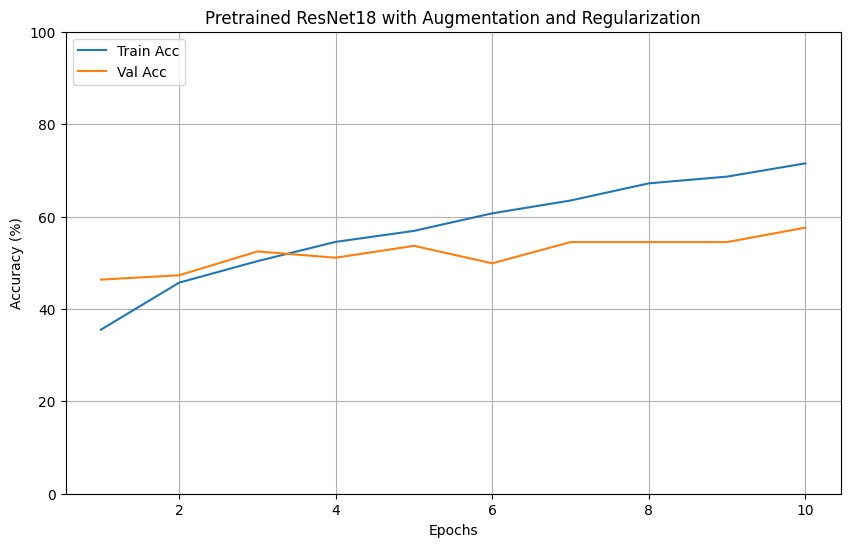


Final Test Accuracy: 61.79%


In [6]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "Pretrained ResNet18 with Augmentation and Regularization")

test_accuracy = evaluate_model(model, test_loader)

### ResNet-18 final version (using everything)

- Using a pretrained model
- Using augmentation and regularization
- Using LR scheduler

Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Epoch 1/15 | Train: 35.65% | Val: 45.12% | LR: 0.000100
Epoch 2/15 | Train: 43.60% | Val: 49.59% | LR: 0.000100
Epoch 3/15 | Train: 48.86% | Val: 52.44% | LR: 0.000100
Epoch 4/15 | Train: 54.07% | Val: 50.54% | LR: 0.000100
Epoch 5/15 | Train: 58.23% | Val: 51.49% | LR: 0.000050
Epoch 6/15 | Train: 62.56% | Val: 53.66% | LR: 0.000050
Epoch 7/15 | Train: 66.54% | Val: 54.88% | LR: 0.000050
Epoch 8/15 | Train: 69.66% | Val: 52.71% | LR: 0.000050
Epoch 9/15 | Train: 71.78% | Val: 55.56% | LR: 0.000050
Epoch 10/15 | Train: 74.74% | Val: 54.61% | LR: 0.000050
Epoch 11/15 | Train: 77.11% | Val: 55.96% | LR: 0.000050
Epoch 12/15 | Train: 79.93% | Val: 57.72% | LR: 0.000050
Epoch 13/15 | Train: 82.44% | Val: 54.74% | LR: 0.000050
Epoch 14/15 | Train: 83.28% | Val: 57.32% | LR: 0.000025
Epoch 15/15 | Train: 88.47% | Val: 58.67% | LR: 0.000025
[0.0001, 0.0001, 0.0001, 0.0001, 5e-05, 5e-05, 5e-05, 5e-05, 5e-05, 5e-05, 5e-05, 5e-05, 5e-05, 2.5e-05, 2.5e-05]


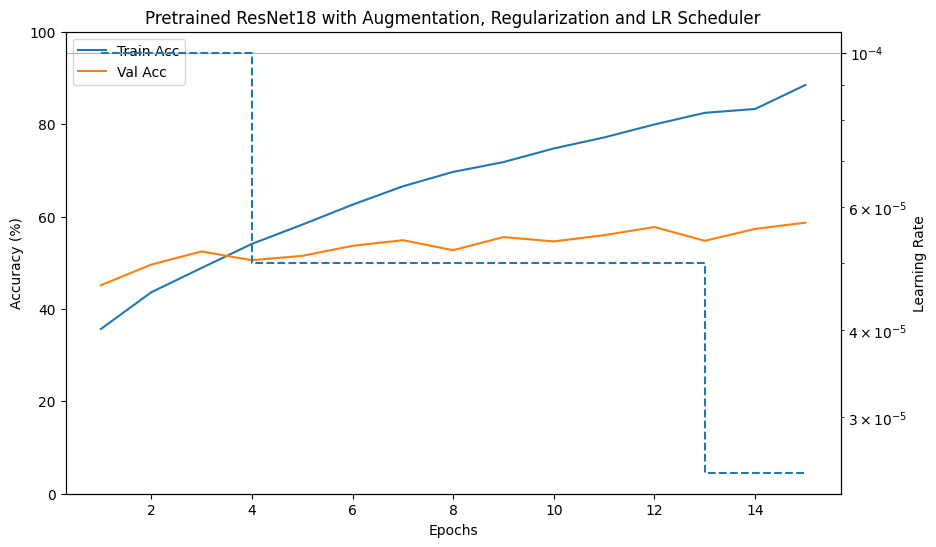


Final Test Accuracy: 63.64%


In [10]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3,
    use_scheduler=True,
    scheduler_factor=0.5,
    scheduler_patience=1
)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    epochs=15
)

plot_history(history, "Pretrained ResNet18 with Augmentation, Regularization and LR Scheduler")

test_accuracy = evaluate_model(model, test_loader)